In [31]:
from FastBEMT.Propeller import Propeller
from FastBEMT.Utils import LowFidelityParameters
from FastBEMT.Utils import Plotter
from FastBEMT.Utils import load_propeller_dict
from FastBEMT.Aeroacoustics import uniform_observer_grid, circular_observer_array
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
plt.style.use(['science', 'no-latex'])

In [32]:
name, blade_dict = load_propeller_dict('../Data/10x7E')[0]

In [33]:
params = LowFidelityParameters(
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    n_blades=blade_dict['n_blades'],
    p_ref=2e-5,
    revolutions=1,
    num_obs_times_per_rev=20,
    device='cuda'
)

In [34]:
propeller = Propeller(
    geometry=blade_dict,
    params=params,
)

propeller.run_bemt(rpm=7000, v_inf=0.0)

C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


In [35]:
thrust, torque, ct, cq, figure_of_merit = propeller.compute_total_forces()
print(f'Propeller: {name}')
print(f'Thrust: {thrust}')
print(f'Torque: {torque}')
print(f'CT: {ct}')
print(f'CQ: {cq}')
print(f'Figure of Merit: {figure_of_merit}')

Propeller: 10x7E
Thrust: 8.059077814540784
Torque: 0.13453791951726007
CT: 0.11612368651504494
CQ: 0.007632142253015371
Figure of Merit: 0.6584077871064794


In [36]:
propeller.run_aeroacoustics(observer_positions=uniform_observer_grid(size=5, nx=26, ny=26),
        lt=0.01,
        i=5e-4,
        alpha_stall=15,
        keep_bpm_components=False)

propeller.postprocess()

[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.


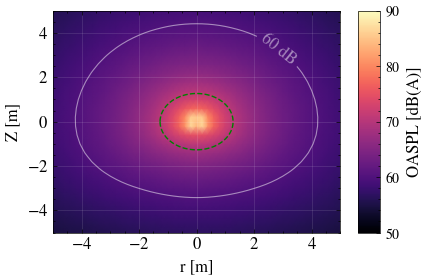

In [37]:
plotter = Plotter(propeller)
plotter.plot_acoustic_map(
    grid_size=26,
    domain_size=5,
    noise_type='total',
    figsize=(4.5, 3),
    cmap='magma',
    mirror=True,
    contour_levels=[60],
    # save_path='../Figures/Validation/acoustic_map10x7E.png'
    save_path=None
)

In [38]:
obs = circular_observer_array(radius=1.88, n_points=36)
propeller.run_aeroacoustics(observer_positions=obs,
        lt=0.1,
        i=5e-4,
        alpha_stall=15,
        keep_bpm_components=False)

propeller.postprocess()

[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.


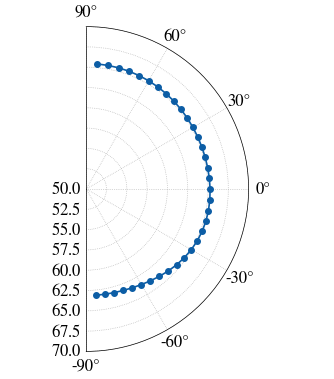

In [39]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='polar')
ax.plot(np.arctan2(obs[:, 0], obs[:, 1]), propeller.third_octave_total_oaspl, '-o', linewidth=1.2, markersize=4)

# --- Final Formatting ---
ax.set_theta_zero_location('E')
ax.set_theta_direction(1)
ax.set_thetamin(-90)
ax.set_thetamax(90)
ax.set_rlabel_position(180)
ax.set_rlim(50,70)

ax.grid(True, alpha=1, linestyle=':')

# Legend placement - moved slightly to avoid overlapping dynamic data
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# Legend placement

plt.tight_layout()
plt.show()

C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


Propeller: 10x7E
Thrust: 8.092956921075103
Torque: 0.15399792816669716
CT: 0.1758689063389204
CQ: 0.01317537532226823
Figure of Merit: 0.7108546223906052
[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.


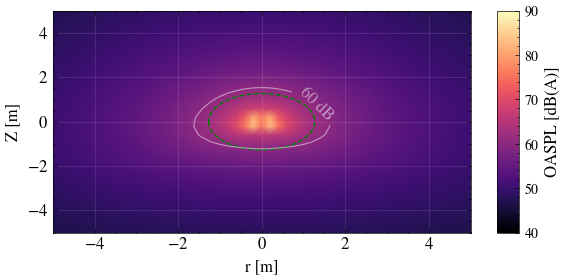

In [40]:
name, blade_dict = load_propeller_dict('../Data/10x7E')[0]

for idx in range(len(blade_dict['r'])):
    blade_dict['chord'][idx] += 0.01

propeller = Propeller(
    geometry=blade_dict,
    params=params,
)

propeller.run_bemt(rpm=5700, v_inf=0.0)

thrust, torque, ct, cq, figure_of_merit = propeller.compute_total_forces()
print(f'Propeller: {name}')
print(f'Thrust: {thrust}')
print(f'Torque: {torque}')
print(f'CT: {ct}')
print(f'CQ: {cq}')
print(f'Figure of Merit: {figure_of_merit}')

propeller.run_aeroacoustics(observer_positions=uniform_observer_grid(size=5, nx=26, ny=26),
        lt=0.1,
        i=5e-4,
        alpha_stall=15,
        keep_bpm_components=False)

propeller.postprocess()

plotter = Plotter(propeller)
plotter.plot_acoustic_map(
    grid_size=26,
    domain_size=5,
    figsize=(6, 3),
    cmap='magma',
    mirror=True,
    contour_levels=[60],
    # save_path='../Figures/Validation/acoustic_map10x7E.png'
    save_path=None
)